## Análise Exploratória — Resume-JD-Match

O dataset **Resume-JD-Match** foi utilizado como a principal base supervisionada do projeto, pois contém pares de currículos e descrições de vagas rotulados de acordo com o grau de compatibilidade entre candidato e oportunidade. Essa base é essencial para a etapa de classificação do JobMatch AI, já que permite treinar um modelo capaz de aprender padrões associados a exemplos classificados como `Fit` e `No Fit`.

A base possui **8.000 registros**, divididos em dois conjuntos: **6.241 exemplos de treino** e **1.759 exemplos de teste**. Originalmente, o dataset contém as colunas `text` e `label`. A coluna `text` armazena o texto completo do exemplo, contendo a descrição da vaga e o currículo do candidato no mesmo campo. A coluna `label` representa o rótulo original de compatibilidade.

Durante o pré-processamento, a coluna `text` foi separada em duas novas colunas: `descricao_vaga` e `curriculo`. Essa separação é fundamental para o projeto, pois a solução final precisa comparar o currículo informado pelo usuário com as descrições das vagas disponíveis. A validação da extração mostrou que todos os **8.000 registros** possuem exatamente dois blocos de texto, ou seja, uma descrição de vaga e um currículo. Além disso, não foram encontrados textos vazios nas colunas extraídas, indicando que a etapa de separação foi bem-sucedida.

A distribuição original dos rótulos apresenta três classes: `No Fit`, `Potential Fit` e `Good Fit`. A classe `No Fit` possui **4.000 registros**, representando **50%** da base. Já as classes `Potential Fit` e `Good Fit` possuem **2.000 registros cada**, representando **25%** da base cada uma. Essa estrutura mostra que o dataset foi construído de forma equilibrada entre exemplos sem compatibilidade e exemplos com algum grau de compatibilidade.

Como a proposta inicial do projeto trabalha com uma classificação binária entre `Fit` e `No Fit`, foi criada uma nova coluna chamada `label_binario`. Nessa transformação, os registros classificados como `No Fit` foram mantidos como `No Fit`, enquanto as classes `Potential Fit` e `Good Fit` foram agrupadas como `Fit`. Após essa conversão, a base ficou perfeitamente balanceada, com **4.000 exemplos Fit** e **4.000 exemplos No Fit**. Esse equilíbrio é positivo para o treinamento inicial do modelo, pois reduz o risco de o algoritmo favorecer uma classe majoritária.

A análise dos splits também mostrou que as proporções dos rótulos são parecidas entre treino e teste. No conjunto de treino, a classe `No Fit` representa aproximadamente **50,36%**, enquanto `Good Fit` representa **24,71%** e `Potential Fit` representa **24,93%**. No conjunto de teste, `No Fit` representa **48,72%**, `Good Fit` representa **26,04%** e `Potential Fit` representa **25,24%**. Isso indica que os conjuntos estão distribuídos de forma consistente, o que é importante para uma avaliação mais confiável do modelo.

Em relação à qualidade dos dados, foi encontrado apenas **1 texto duplicado** e **1 par duplicado** considerando descrição da vaga, currículo e rótulo. Como a quantidade é muito pequena em relação ao total de 8.000 registros, isso não compromete a análise exploratória. Ainda assim, esse ponto deve ser considerado antes da modelagem, pois duplicatas podem influenciar levemente a avaliação do modelo.

A análise do tamanho dos textos mostrou que os currículos são, em média, maiores que as descrições das vagas. O texto completo possui média de aproximadamente **8.625 caracteres**. As descrições das vagas possuem média de **2.777 caracteres** e cerca de **378 palavras**, enquanto os currículos possuem média de **5.773 caracteres** e cerca de **704 palavras**. Esses valores indicam que o dataset possui conteúdo textual suficiente para aplicação de técnicas de Processamento de Linguagem Natural, como TF-IDF, similaridade por cosseno e modelos de classificação textual.

Ao comparar o tamanho dos textos por classe, foi observado que as descrições associadas à classe `Good Fit` são, em média, um pouco maiores do que as demais. A classe `Good Fit` apresentou média de aproximadamente **406 palavras** nas descrições de vaga, enquanto `No Fit` apresentou cerca de **373 palavras** e `Potential Fit` cerca de **363 palavras**. Já os currículos possuem tamanhos médios bastante próximos entre as classes, variando em torno de 700 palavras. Isso indica que a diferença entre as classes não está simplesmente no tamanho dos currículos, mas provavelmente na relação semântica entre currículo e vaga.

Uma análise importante foi o cálculo da similaridade textual entre currículo e descrição da vaga utilizando TF-IDF e similaridade por cosseno. Os resultados mostraram que a similaridade média cresce conforme o nível de compatibilidade aumenta. A classe `No Fit` apresentou similaridade média de **0,0919**, a classe `Potential Fit` apresentou **0,1125** e a classe `Good Fit` apresentou **0,1252**. Essa diferença sugere que existe uma relação entre proximidade textual e compatibilidade, o que reforça o uso de técnicas de NLP para o problema.

Na versão binária, os exemplos classificados como `Fit` apresentaram similaridade média de **0,1189**, enquanto os exemplos `No Fit` apresentaram média de **0,0919**. Isso mostra que, em média, currículos compatíveis tendem a ser mais semelhantes às descrições das vagas do que currículos não compatíveis. Porém, essa diferença não é extremamente grande, o que indica que a similaridade por cosseno sozinha provavelmente não será suficiente para resolver todo o problema. Por isso, ela deve ser usada como uma das informações do sistema, mas não necessariamente como único critério de decisão.

Também foram analisados os termos mais relevantes nas descrições de vagas e nos currículos. Nas descrições de vagas, apareceram com maior destaque termos como `experience`, `data`, `business`, `accounting`, `software`, `team`, `work`, `skills`, `development` e `years`. Já nos currículos, os termos mais relevantes incluíram `data`, `business`, `sql`, `using`, `test`, `testing`, `management`, `software`, `development` e `project`. Essa análise mostra que a base possui forte presença de áreas como tecnologia, dados, negócios, contabilidade e desenvolvimento de software.

De forma geral, a EDA mostrou que o Resume-JD-Match é adequado para treinar o modelo supervisionado do projeto. Ele possui uma quantidade razoável de exemplos, textos bem estruturados, rótulos balanceados na versão binária e evidências de que a similaridade textual entre currículo e vaga está relacionada ao grau de compatibilidade.

Dessa forma, esse dataset será utilizado principalmente para treinar e avaliar o modelo de classificação `Fit / No Fit`. Ele não será a base principal de vagas reais para recomendação, papel que ficará com o LinkedIn Job Postings, mas será responsável por ensinar o modelo a reconhecer padrões de aderência entre currículos e descrições de vagas. Posteriormente, esse aprendizado poderá ser aplicado sobre vagas reais para gerar o score de compatibilidade e apoiar o ranking de oportunidades mais aderentes ao perfil informado pelo usuário.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
dataset = load_dataset("facehuggerapoorv/resume-jd-match")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

df_train["split"] = "train"
df_test["split"] = "test"

df = pd.concat([df_train, df_test], ignore_index=True)

print("Formato treino:", df_train.shape)
print("Formato teste:", df_test.shape)
print("Formato total:", df.shape)

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/411 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.07M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

Formato treino: (6241, 3)
Formato teste: (1759, 3)
Formato total: (8000, 3)


,text,label,split
0,For the given job description <<Net2Source Inc. is an award-winning total workforce solutions company recognized by ...,No Fit,train
1,For the given job description <<At Salas OBrien we tell our clients that were engineered for impact. This passion fo...,No Fit,train
2,For the given job description <<Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a ta...,No Fit,train
3,"For the given job description <<Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!T...",No Fit,train
4,For the given job description <<Life at Capgemini\nCapgemini supports all aspects of your well-being throughout the ...,No Fit,train


In [3]:
print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

print("\nColunas:")
for coluna in df.columns:
    print("-", coluna)

print("\nTipos de dados:")
display(df.dtypes)

Quantidade de linhas: 8000
Quantidade de colunas: 3

Colunas:
- text
- label
- split

Tipos de dados:


,0
text,object
label,object
split,object


split
train    6241
test     1759
Name: count, dtype: int64


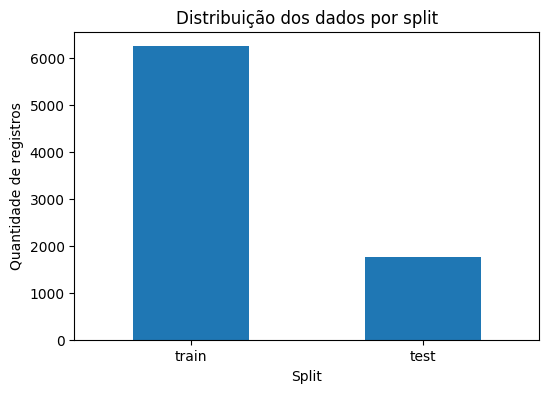

In [4]:
contagem_splits = df["split"].value_counts()

print(contagem_splits)

plt.figure(figsize=(6, 4))
contagem_splits.plot(kind="bar")
plt.title("Distribuição dos dados por split")
plt.xlabel("Split")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=0)
plt.show()

,quantidade,percentual
label,,
No Fit,4000,50.0
Potential Fit,2000,25.0
Good Fit,2000,25.0


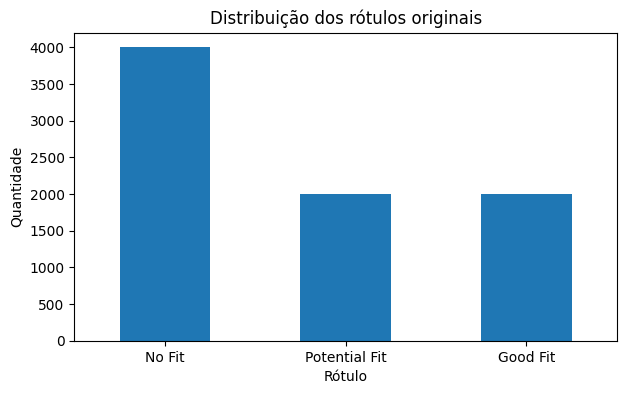

In [5]:
contagem_rotulos = df["label"].value_counts()
percentual_rotulos = df["label"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "quantidade": contagem_rotulos,
    "percentual": percentual_rotulos.round(2)
}))

plt.figure(figsize=(7, 4))
contagem_rotulos.plot(kind="bar")
plt.title("Distribuição dos rótulos originais")
plt.xlabel("Rótulo")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [6]:
distribuicao_split_label = pd.crosstab(
    df["split"],
    df["label"],
    margins=True
)

display(distribuicao_split_label)

distribuicao_percentual = pd.crosstab(
    df["split"],
    df["label"],
    normalize="index"
) * 100

display(distribuicao_percentual.round(2))

label,Good Fit,No Fit,Potential Fit,All
split,,,,
test,458,857,444,1759
train,1542,3143,1556,6241
All,2000,4000,2000,8000


label,Good Fit,No Fit,Potential Fit
split,,,
test,26.04,48.72,25.24
train,24.71,50.36,24.93


In [7]:
def extrair_blocos_texto(texto):
    if pd.isna(texto):
        return pd.Series([None, None])

    blocos = re.findall(r"<<(.*?)>>", str(texto), flags=re.DOTALL)

    descricao_vaga = blocos[0].strip() if len(blocos) >= 1 else None
    curriculo = blocos[1].strip() if len(blocos) >= 2 else None

    return pd.Series([descricao_vaga, curriculo])


df[["descricao_vaga", "curriculo"]] = df["text"].apply(extrair_blocos_texto)

df[["text", "label", "descricao_vaga", "curriculo"]].head()

,text,label,descricao_vaga,curriculo
0,For the given job description <<Net2Source Inc. is an award-winning total workforce solutions company recognized by ...,No Fit,Net2Source Inc. is an award-winning total workforce solutions company recognized by Staffing Industry Analysts for o...,SummaryHighly motivated Sales Associate with extensive customer service and sales experience. Outgoing sales profess...
1,For the given job description <<At Salas OBrien we tell our clients that were engineered for impact. This passion fo...,No Fit,At Salas OBrien we tell our clients that were engineered for impact. This passion for making a difference applies ju...,Professional SummaryCurrently working with Caterpillar as an contract employee Active in several NPI and CPI project...
2,For the given job description <<Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a ta...,No Fit,Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a talented individual for a cybersec...,"SummaryI started my construction career in June of 2017 in Jacksonville, Florida as an Electrical Apprentice working..."
3,"For the given job description <<Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!T...",No Fit,"Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!This is a great opportunity for t...",SummaryCertified Electrical Foremanwith thirteen years of experience in the implementation of electrical systems on ...
4,For the given job description <<Life at Capgemini\nCapgemini supports all aspects of your well-being throughout the ...,No Fit,Life at Capgemini\nCapgemini supports all aspects of your well-being throughout the changing stages of your life and...,SummaryWith extensive experience in business/requirement analysis with SDLC processing. Experience includes project ...


In [8]:
df["qtd_blocos_extraidos"] = df["text"].apply(
    lambda texto: len(re.findall(r"<<(.*?)>>", str(texto), flags=re.DOTALL))
)

print("Distribuição da quantidade de blocos extraídos:")
print(df["qtd_blocos_extraidos"].value_counts().sort_index())

descricoes_vazias = df["descricao_vaga"].fillna("").astype(str).str.strip().eq("").sum()
curriculos_vazios = df["curriculo"].fillna("").astype(str).str.strip().eq("").sum()

print("\nDescrições de vaga vazias:", descricoes_vazias)
print("Currículos vazios:", curriculos_vazios)

Distribuição da quantidade de blocos extraídos:
qtd_blocos_extraidos
2    8000
Name: count, dtype: int64

Descrições de vaga vazias: 0
Currículos vazios: 0


,quantidade,percentual
label_binario,,
No Fit,4000,50.0
Fit,4000,50.0


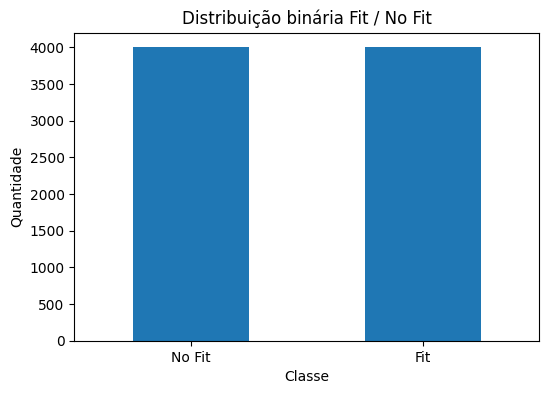

In [9]:
def converter_para_binario(rotulo):
    rotulo = str(rotulo).strip().lower()

    if rotulo == "no fit":
        return "No Fit"

    return "Fit"


df["label_binario"] = df["label"].apply(converter_para_binario)

contagem_binaria = df["label_binario"].value_counts()
percentual_binario = df["label_binario"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "quantidade": contagem_binaria,
    "percentual": percentual_binario.round(2)
}))

plt.figure(figsize=(6, 4))
contagem_binaria.plot(kind="bar")
plt.title("Distribuição binária Fit / No Fit")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [10]:
duplicatas_texto = df["text"].duplicated().sum()
duplicatas_par = df[["descricao_vaga", "curriculo", "label"]].duplicated().sum()

print("Textos completos duplicados:", duplicatas_texto)
print("Pares descrição + currículo + label duplicados:", duplicatas_par)

Textos completos duplicados: 1
Pares descrição + currículo + label duplicados: 1


In [11]:
df["tamanho_texto_completo"] = df["text"].fillna("").astype(str).str.len()
df["tamanho_descricao_vaga"] = df["descricao_vaga"].fillna("").astype(str).str.len()
df["tamanho_curriculo"] = df["curriculo"].fillna("").astype(str).str.len()

df["palavras_texto_completo"] = df["text"].fillna("").astype(str).str.split().str.len()
df["palavras_descricao_vaga"] = df["descricao_vaga"].fillna("").astype(str).str.split().str.len()
df["palavras_curriculo"] = df["curriculo"].fillna("").astype(str).str.split().str.len()

resumo_tamanhos = df[[
    "tamanho_texto_completo",
    "tamanho_descricao_vaga",
    "tamanho_curriculo",
    "palavras_texto_completo",
    "palavras_descricao_vaga",
    "palavras_curriculo"
]].describe().round(2)

display(resumo_tamanhos)

,tamanho_texto_completo,tamanho_descricao_vaga,tamanho_curriculo,palavras_texto_completo,palavras_descricao_vaga,palavras_curriculo
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,8624.83,2776.77,5773.37,1094.60,378.44,704.39
std,3417.29,1777.20,2958.11,457.02,249.87,387.03
min,1497.00,72.00,897.00,169.00,11.00,84.00
25%,6326.00,1307.00,4234.00,782.00,169.00,488.00
50%,7996.50,2401.00,5123.00,1009.00,326.00,618.00
75%,10201.00,3985.00,6603.00,1310.25,552.00,809.00
max,30939.00,8171.00,25364.00,3920.00,1254.00,3134.00


In [12]:
resumo_por_classe = df.groupby("label")[[
    "tamanho_descricao_vaga",
    "tamanho_curriculo",
    "palavras_descricao_vaga",
    "palavras_curriculo"
]].mean().round(2)

display(resumo_por_classe)

,tamanho_descricao_vaga,tamanho_curriculo,palavras_descricao_vaga,palavras_curriculo
label,,,,
Good Fit,2980.96,5712.42,405.86,700.06
No Fit,2735.21,5800.25,372.53,706.03
Potential Fit,2655.70,5780.56,362.83,705.45


<Figure size 800x500 with 0 Axes>

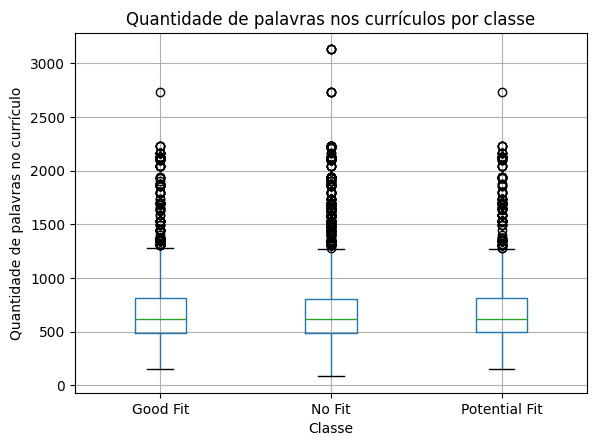

In [13]:
plt.figure(figsize=(8, 5))
df.boxplot(column="palavras_curriculo", by="label")
plt.title("Quantidade de palavras nos currículos por classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Quantidade de palavras no currículo")
plt.xticks(rotation=0)
plt.show()

<Figure size 800x500 with 0 Axes>

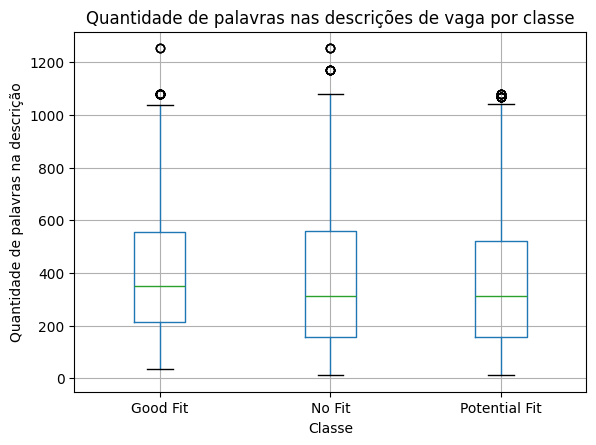

In [14]:
plt.figure(figsize=(8, 5))
df.boxplot(column="palavras_descricao_vaga", by="label")
plt.title("Quantidade de palavras nas descrições de vaga por classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Quantidade de palavras na descrição")
plt.xticks(rotation=0)
plt.show()

In [15]:
def calcular_similaridade_linha(descricao, curriculo):
    textos = [
        "" if pd.isna(descricao) else str(descricao),
        "" if pd.isna(curriculo) else str(curriculo)
    ]

    if textos[0].strip() == "" or textos[1].strip() == "":
        return np.nan

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000
    )

    matriz = vectorizer.fit_transform(textos)

    return cosine_similarity(matriz[0], matriz[1])[0][0]


df["similaridade_tfidf"] = df.apply(
    lambda linha: calcular_similaridade_linha(
        linha["descricao_vaga"],
        linha["curriculo"]
    ),
    axis=1
)

df[["label", "label_binario", "similaridade_tfidf"]].head()

,label,label_binario,similaridade_tfidf
0,No Fit,No Fit,0.076694
1,No Fit,No Fit,0.105820
2,No Fit,No Fit,0.076469
3,No Fit,No Fit,0.040324
4,No Fit,No Fit,0.082564


,count,mean,median,min,max,std
label,,,,,,
Good Fit,2000,0.1252,0.1069,0.0034,0.5360,0.0763
No Fit,4000,0.0919,0.0736,0.0000,0.6312,0.0726
Potential Fit,2000,0.1125,0.0978,0.0000,0.5033,0.0712


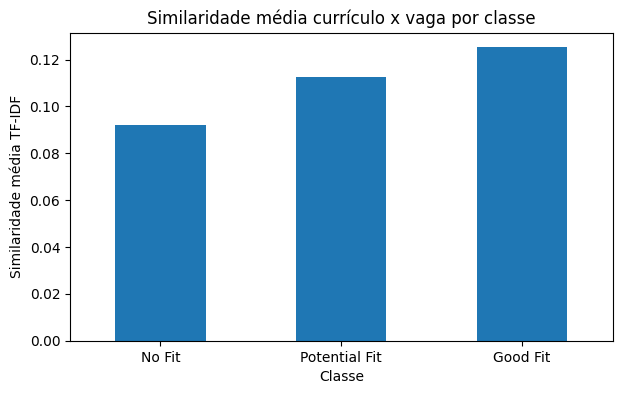

In [16]:
similaridade_por_classe = df.groupby("label")["similaridade_tfidf"].agg(
    ["count", "mean", "median", "min", "max", "std"]
).round(4)

display(similaridade_por_classe)

plt.figure(figsize=(7, 4))
df.groupby("label")["similaridade_tfidf"].mean().sort_values().plot(kind="bar")
plt.title("Similaridade média currículo x vaga por classe")
plt.xlabel("Classe")
plt.ylabel("Similaridade média TF-IDF")
plt.xticks(rotation=0)
plt.show()

,count,mean,median,min,max,std
label_binario,,,,,,
Fit,4000,0.1189,0.1024,0.0,0.5360,0.0741
No Fit,4000,0.0919,0.0736,0.0,0.6312,0.0726


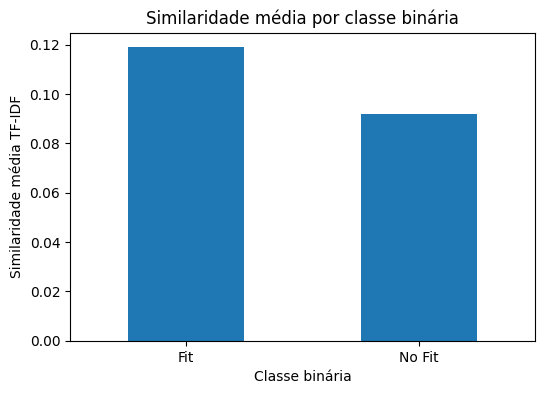

In [17]:
similaridade_binaria = df.groupby("label_binario")["similaridade_tfidf"].agg(
    ["count", "mean", "median", "min", "max", "std"]
).round(4)

display(similaridade_binaria)

plt.figure(figsize=(6, 4))
df.groupby("label_binario")["similaridade_tfidf"].mean().plot(kind="bar")
plt.title("Similaridade média por classe binária")
plt.xlabel("Classe binária")
plt.ylabel("Similaridade média TF-IDF")
plt.xticks(rotation=0)
plt.show()

,termo,peso_tfidf
1771,experience,503.681364
1224,data,499.206582
693,business,373.610741
189,accounting,342.529961
4226,software,340.033823
4505,team,275.281066
4948,work,262.107521
4182,skills,243.193680
1367,development,242.539606
4984,years,228.755387


<Figure size 1000x700 with 0 Axes>

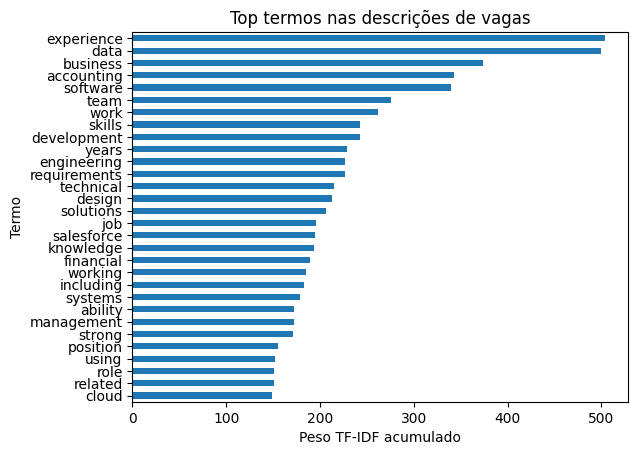

In [18]:
def obter_top_termos(textos, n=30):
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=5000
    )

    matriz = vectorizer.fit_transform(textos.fillna("").astype(str))
    termos = vectorizer.get_feature_names_out()
    soma_tfidf = matriz.sum(axis=0).A1

    resultado = pd.DataFrame({
        "termo": termos,
        "peso_tfidf": soma_tfidf
    }).sort_values("peso_tfidf", ascending=False)

    return resultado.head(n)


top_termos_vagas = obter_top_termos(df["descricao_vaga"], n=30)

display(top_termos_vagas)

plt.figure(figsize=(10, 7))
top_termos_vagas.sort_values("peso_tfidf").plot(
    kind="barh",
    x="termo",
    y="peso_tfidf",
    legend=False
)
plt.title("Top termos nas descrições de vagas")
plt.xlabel("Peso TF-IDF acumulado")
plt.ylabel("Termo")
plt.show()

,termo,peso_tfidf
1230,data,673.104329
706,business,339.332382
4276,sql,338.193620
4760,using,327.279574
4556,test,324.108981
4560,testing,317.836459
2746,management,287.820767
4206,software,281.912253
1374,development,258.600444
3536,project,252.855970


<Figure size 1000x700 with 0 Axes>

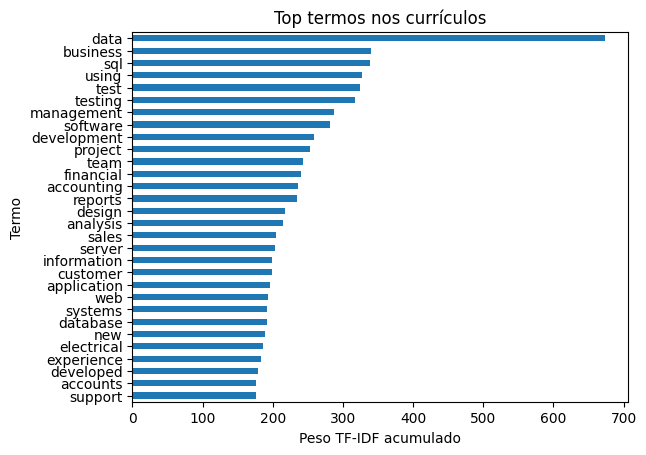

In [19]:
top_termos_curriculos = obter_top_termos(df["curriculo"], n=30)

display(top_termos_curriculos)

plt.figure(figsize=(10, 7))
top_termos_curriculos.sort_values("peso_tfidf").plot(
    kind="barh",
    x="termo",
    y="peso_tfidf",
    legend=False
)
plt.title("Top termos nos currículos")
plt.xlabel("Peso TF-IDF acumulado")
plt.ylabel("Termo")
plt.show()

In [20]:
for classe in df["label"].unique():
    print("=" * 100)
    print("Classe:", classe)

    exemplo = df[df["label"] == classe].sample(1, random_state=42).iloc[0]

    print("\nTrecho da descrição da vaga:")
    print(exemplo["descricao_vaga"][:700])

    print("\nTrecho do currículo:")
    print(exemplo["curriculo"][:700])

Classe: No Fit

Trecho da descrição da vaga:
My client is seeking a Staff Accountant to come in and join their rapidly growing team. This individual will gain great exposure to each facet of the Accounting cycle within a top-tier Hedge Fund. Client DetailsMy client is a sophisticated Hedge Fund located in Old Greenwich, CT. DescriptionManage financial operations of all US multi-state officesAnalyze and process accounts payable and all other financial activityAssist with completion of global consolidated auditAnalyze company ledger accounts actual to budget, month over month, and annual trendsBecome a knowledge center for all US financial activity and expense policiesAssist with project management activities, including development and m

Trecho do currículo:
Summary7+ years of experience as a BI developer with a proven track record in Business Intelligence (BI), Data Warehouse (DWH) and Data Analytics related consulting projects.Proven ability to identify business needs and develop valu

In [21]:
df_processado = df[[
    "split",
    "text",
    "descricao_vaga",
    "curriculo",
    "label",
    "label_binario",
    "qtd_blocos_extraidos",
    "tamanho_texto_completo",
    "tamanho_descricao_vaga",
    "tamanho_curriculo",
    "palavras_texto_completo",
    "palavras_descricao_vaga",
    "palavras_curriculo",
    "similaridade_tfidf"
]].copy()

df_processado.head()

,split,text,descricao_vaga,curriculo,label,label_binario,qtd_blocos_extraidos,tamanho_texto_completo,tamanho_descricao_vaga,tamanho_curriculo,palavras_texto_completo,palavras_descricao_vaga,palavras_curriculo,similaridade_tfidf
0,train,For the given job description <<Net2Source Inc. is an award-winning total workforce solutions company recognized by ...,Net2Source Inc. is an award-winning total workforce solutions company recognized by Staffing Industry Analysts for o...,SummaryHighly motivated Sales Associate with extensive customer service and sales experience. Outgoing sales profess...,No Fit,No Fit,2,10730,3958,6698,1365,559,794,0.076694
1,train,For the given job description <<At Salas OBrien we tell our clients that were engineered for impact. This passion fo...,At Salas OBrien we tell our clients that were engineered for impact. This passion for making a difference applies ju...,Professional SummaryCurrently working with Caterpillar as an contract employee Active in several NPI and CPI project...,No Fit,No Fit,2,10455,3808,6573,1443,568,863,0.105820
2,train,For the given job description <<Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a ta...,Schweitzer Engineering Laboratories (SEL) Infrastructure Defense Division seeks a talented individual for a cybersec...,"SummaryI started my construction career in June of 2017 in Jacksonville, Florida as an Electrical Apprentice working...",No Fit,No Fit,2,10475,3193,7208,1322,438,872,0.076469
3,train,"For the given job description <<Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!T...","Mizick Miller & Company, Inc. is looking for a dynamic individual to join our team!This is a great opportunity for t...",SummaryCertified Electrical Foremanwith thirteen years of experience in the implementation of electrical systems on ...,No Fit,No Fit,2,6866,1097,5695,860,164,684,0.040324
4,train,For the given job description <<Life at Capgemini\nCapgemini supports all aspects of your well-being throughout the ...,Life at Capgemini\nCapgemini supports all aspects of your well-being throughout the changing stages of your life and...,SummaryWith extensive experience in business/requirement analysis with SDLC processing. Experience includes project ...,No Fit,No Fit,2,19226,6174,12978,2678,877,1789,0.082564


In [22]:
print("Resumo final da EDA — Resume-JD-Match")
print("=" * 70)

print("\n1. Quantidade total de registros:")
print(df.shape[0])

print("\n2. Quantidade de registros por split:")
print(df["split"].value_counts())

print("\n3. Colunas originais:")
print(["text", "label"])

print("\n4. Colunas criadas:")
print([
    "descricao_vaga",
    "curriculo",
    "label_binario",
    "qtd_blocos_extraidos",
    "tamanho_descricao_vaga",
    "tamanho_curriculo",
    "palavras_descricao_vaga",
    "palavras_curriculo",
    "similaridade_tfidf"
])

print("\n5. Distribuição original dos rótulos:")
print(df["label"].value_counts())

print("\n6. Distribuição binária Fit / No Fit:")
print(df["label_binario"].value_counts())

print("\n7. Textos vazios:")
print("Descrições vazias:", descricoes_vazias)
print("Currículos vazios:", curriculos_vazios)

print("\n8. Tamanho médio em palavras:")
print("Descrição da vaga:", round(df["palavras_descricao_vaga"].mean(), 2))
print("Currículo:", round(df["palavras_curriculo"].mean(), 2))

print("\n9. Similaridade média por classe original:")
print(df.groupby("label")["similaridade_tfidf"].mean().round(4))

print("\n10. Como esse dataset será usado no projeto?")
print(
    "Este dataset será usado para treinar o modelo supervisionado de classificação Fit / No Fit. "
    "Ele contém pares de descrição de vaga e currículo rotulados quanto ao grau de compatibilidade. "
    "A partir dele, será possível treinar e avaliar modelos de NLP para prever se um candidato possui aderência a uma vaga."
)

Resumo final da EDA — Resume-JD-Match

1. Quantidade total de registros:
8000

2. Quantidade de registros por split:
split
train    6241
test     1759
Name: count, dtype: int64

3. Colunas originais:
['text', 'label']

4. Colunas criadas:
['descricao_vaga', 'curriculo', 'label_binario', 'qtd_blocos_extraidos', 'tamanho_descricao_vaga', 'tamanho_curriculo', 'palavras_descricao_vaga', 'palavras_curriculo', 'similaridade_tfidf']

5. Distribuição original dos rótulos:
label
No Fit           4000
Potential Fit    2000
Good Fit         2000
Name: count, dtype: int64

6. Distribuição binária Fit / No Fit:
label_binario
No Fit    4000
Fit       4000
Name: count, dtype: int64

7. Textos vazios:
Descrições vazias: 0
Currículos vazios: 0

8. Tamanho médio em palavras:
Descrição da vaga: 378.44
Currículo: 704.39

9. Similaridade média por classe original:
label
Good Fit         0.1252
No Fit           0.0919
Potential Fit    0.1125
Name: similaridade_tfidf, dtype: float64

10. Como esse dataset se